# Table of Contents

1. [Project Overview](#Project-Overview)
2. [Dataset](#dataset)
3. [Model Architecture (From Scratch)](#Model-Architecture-From-Scratch)
4. [Baseline Implementation](#Baseline-Implementation)
5. [Optimization Techniques](#Optimization-Techniques)
6. [Evaluation Metrics](#Evaluation-Metrics)
7. [Ablation Study](#Ablation-Study)
    - [Learning Rate Comparisons](#Learning-Rate-Comparisons)
    - [Regularization](#Regularization)
        - [Effect of Dropout Probability](#Effect-of-Dropout-Probability)
        - [Effect of L2 Regularization Strength](#Effect-of-L2-Regularization-Strength)
    - [Effect of Optimization Algorithm](#Effect-of-Optimization-Algorithm)
    - [Effect of Adam Hyperparameters](#Effect-of-Adam-Hyperparameters)
8. [Final Model Configuration](#Final-Model-Configuration)
9. [Results and Discussion](#Results-and-Discussion)
10. [Conclusion](#Conclusion)

## Project Overview

This project implements a neural network from scratch to classify CIFAR-10 images.  
The objective is to achieve at least 75% test accuracy.  

An ablation study is conducted to evaluate:
- Learning rate decay strategies  
- Regularization methods (L2, Dropout)  
- Optimization algorithms (SGD, Momentum, Adam)  
- Adam hyperparameter sensitivity  

## Dataset

In [1]:
import torch
import torch.nn as nn
import math
from torch.utils.data import Dataset
from torchvision import datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from util import get_device
from evaluations import train_model
from model.model import Model
import os

In [2]:
# CIFAR-10 normalization stats
cifar_mean = [0.485, 0.456, 0.406]
cifar_std  = [0.229, 0.224, 0.225]


# Training transforms (with augmentation + normalization)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar_mean, std=cifar_std)
])


# Test transforms (NO augmentation, but WITH normalization)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar_mean, std=cifar_std)
])


training_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=train_transform
)

test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=test_transform
)

#workers
workers = os.cpu_count()
print(f"Setting number of workers to available CPU cores: {workers}")
from torch.utils.data import DataLoader
batch_size = 128
train_loader = torch.utils.data.DataLoader(training_data, batch_size=batch_size, shuffle=True, num_workers=workers, pin_memory=True, persistent_workers=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=workers, pin_memory=True, persistent_workers=True)

Setting number of workers to available CPU cores: 24


### Data Format & Batch Creation

In [3]:
from model.model import Model
image, label = training_data[0]
print(image.shape)
print("Label: ", label)

print("All Class Labels: \n", training_data.classes)

for images, labels in train_loader:
    print("images: [batch_size, channels, height, width]")
    print(images.shape)
    print("labels: [batch_size]")
    print(labels.shape)

    break


torch.Size([3, 32, 32])
Label:  6
All Class Labels: 
 ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
images: [batch_size, channels, height, width]
torch.Size([128, 3, 32, 32])
labels: [batch_size]
torch.Size([128])


# Example images

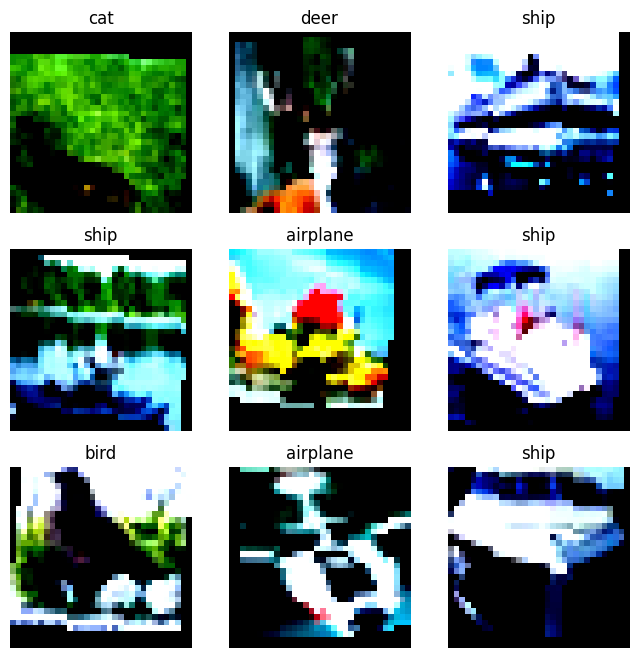

In [4]:
from util import show_random_images
show_random_images(training_data)


## Create model (Pytorch Implementation)

### Layer Creation

In [5]:
device = get_device()

Intel XPU detected
Set to use device: xpu


In [ ]:
main_model = Model()
train_model(
    model=main_model,
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    epochs=100,
    lr=0.001,
    optimizer_type="csi5140_adam",
    weight_decay=1e-4,
    learn_rate_type="cosine",
    gamma=0.9
)

Epoch 1: Loss 1.7581, Train 34.47%, Test 39.32%
Epoch 2: Loss 1.6382, Train 39.68%, Test 39.72%
Epoch 3: Loss 1.6482, Train 39.81%, Test 34.29%
Epoch 4: Loss 1.6803, Train 38.59%, Test 38.36%
Epoch 5: Loss 1.6902, Train 38.18%, Test 34.93%
Epoch 6: Loss 1.7034, Train 37.12%, Test 35.52%
Epoch 7: Loss 1.6997, Train 36.91%, Test 34.55%
Epoch 8: Loss 1.7009, Train 36.98%, Test 37.60%
Epoch 9: Loss 1.6938, Train 36.86%, Test 38.84%
Epoch 10: Loss 1.6829, Train 37.64%, Test 40.76%
Epoch 11: Loss 1.6817, Train 37.69%, Test 28.58%
Epoch 12: Loss 1.6755, Train 38.05%, Test 30.84%
Epoch 13: Loss 1.6695, Train 37.81%, Test 39.36%
Epoch 14: Loss 1.6569, Train 38.77%, Test 39.41%
Epoch 15: Loss 1.6596, Train 38.74%, Test 41.22%
Epoch 16: Loss 1.6447, Train 39.40%, Test 35.90%
Epoch 17: Loss 1.6468, Train 39.22%, Test 42.82%
Epoch 18: Loss 1.6450, Train 39.22%, Test 40.43%
Epoch 19: Loss 1.6401, Train 39.41%, Test 40.08%
Epoch 20: Loss 1.6393, Train 39.54%, Test 40.68%
Epoch 21: Loss 1.6321, Train 

In [ ]:
# torch.save(model.state_dict(), "cifar10_model_adam_normalize.pth")

# Abalation Study

## Base Model

In [ ]:
base_model, base_train_accs, base_test_accs, base_train_costs = train_model(
    model=Model(),
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    epochs=5,
    lr=0.01,
    optimizer_type="sgd",
    weight_decay=0.0,
    learn_rate_type=None
)
print(f"Base Model Stats: \nTrain Accuracy (Per Epoch): {base_train_accs}\nTest Accuracy (Per Epoch): {base_test_accs} \nLoss Per Iteration: {base_train_costs}")

## Regularization

### L2 Regularization 

### Dropout

## Optimization Algorithms

### Cosine Decay

### Adam - Beta1 & Beta2